In [1]:
import pandas as pd 
import os

In [ ]:
# Checking how many of each label is present in the training data
from collections import Counter

def counting(folder_path):
# Initialize a counter for the labels 0, 1, 2, 3, 4
    label_counts = Counter({0: 0, 1: 0, 2: 0, 3: 0})

    # Loop through each file in the directory
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        # Make sure it's a file, not a subfolder
        if os.path.isfile(file_path):
            try:
                with open(file_path, "r", encoding="utf-8") as f:
                    line = f.readline().strip()

                    if line:  # Check if the line is not empty
                        # Split by whitespace and grab the first item
                        parts = line.split()
                        label = int(parts[0])

                        # Only count if it's one of the target labels
                        if label in label_counts:
                            label_counts[label] += 1
            except (ValueError, IndexError):
                # Skips files that are empty, misformatted, or don't start with an integer
                continue

    # Print the results
    for label in sorted(label_counts.keys()):
        print(f"Label {label}: {label_counts[label]} files")

In [ ]:
FOLDER_NAME1 = "/Users/yatharthnehva/Desktop/CVP_Project/data/tealeafagequality/train/labels"
FOLDER_NAME2 = "/Users/yatharthnehva/Desktop/CVP_Project/data/tealeafagequality/test/labels"
FOLDER_NAME3 = "/Users/yatharthnehva/Desktop/CVP_Project/data/tealeafagequality/valid/labels"

print("Training Data Label Counts:")
counting(FOLDER_NAME1)
print("\nTesting Data Label Counts:")
counting(FOLDER_NAME2)
print("\nValidation Data Label Counts:")
counting(FOLDER_NAME3)

Training Data Label Counts:
Label 0: 374 files
Label 1: 437 files
Label 2: 356 files
Label 3: 372 files

Testing Data Label Counts:
Label 0: 55 files
Label 1: 64 files
Label 2: 54 files
Label 3: 45 files

Validation Data Label Counts:
Label 0: 122 files
Label 1: 115 files
Label 2: 98 files
Label 3: 103 files


# Beginning with the tea leaf detection pipeline

In [ ]:
# Step 1 - Inspecting the datasets we just downloaded -> Tea.plantation.v37 and Tea.v2i
# Step A - imports and package downloads
! pip install ultralytics pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.5 MB/s eta 0:00:00-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.8/865.8 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 MB 7.3 MB/s eta 0:00:0000:0100:01m
  Attempting uninstall: httpx
    Found existing installation: httpx 0.27.0
    Uninstalling httpx-0.27.0:
      Successfully uninstalled httpx-0.27.0


In [ ]:
from pathlib import Path
import json

datasets = {
    "tea": Path("/Users/yatharthnehva/Desktop/CVP_Project/data/tea.v2i.coco"),
    "tea_plantation": Path("/Users/yatharthnehva/Desktop/CVP_Project/data/Tea Plantation.v37i.coco-segmentation"),
}

for dataset_name, dataset_path in datasets.items():

    print("\n" + "=" * 70)
    print(dataset_name.upper())
    print("=" * 70)

    for split in ["train", "valid", "test"]:

        split_path = dataset_path / split
        json_files = list(split_path.glob("*.json"))

        print(f"\n--- {split.upper()} ---")

        if not json_files:
            print("❌ No JSON file found")
            continue

        json_file = json_files[0]

        with open(json_file, "r") as f:
            data = json.load(f)

        print("JSON:", json_file.name)
        print("Images:", len(data.get("images", [])))
        print("Annotations:", len(data.get("annotations", [])))

        print("Classes:")

        for category in data.get("categories", []):
            print(
                f"  {category['id']} → {category['name']}"
            )

        # Count annotations per class
        class_counts = {}

        for ann in data.get("annotations", []):
            cid = ann["category_id"]
            class_counts[cid] = class_counts.get(cid, 0) + 1

        print("Annotation counts:")

        for category in data.get("categories", []):
            cid = category["id"]
            name = category["name"]
            count = class_counts.get(cid, 0)

            print(f"  {name}: {count}")


TEA

--- TRAIN ---
JSON: _annotations.coco.json
Images: 1080
Annotations: 1764
Classes:
  0 → tea-leaf
  1 → Singlebud
  2 → oneleafOnebud
  3 → threeleafOnebud
  4 → twoleafOnebud
Annotation counts:
  tea-leaf: 0
  Singlebud: 285
  oneleafOnebud: 465
  threeleafOnebud: 93
  twoleafOnebud: 921

--- VALID ---
JSON: _annotations.coco.json
Images: 102
Annotations: 130
Classes:
  0 → tea-leaf
  1 → Singlebud
  2 → oneleafOnebud
  3 → threeleafOnebud
  4 → twoleafOnebud
Annotation counts:
  tea-leaf: 0
  Singlebud: 14
  oneleafOnebud: 34
  threeleafOnebud: 7
  twoleafOnebud: 75

--- TEST ---
JSON: _annotations.coco.json
Images: 50
Annotations: 65
Classes:
  0 → tea-leaf
  1 → Singlebud
  2 → oneleafOnebud
  3 → threeleafOnebud
  4 → twoleafOnebud
Annotation counts:
  tea-leaf: 0
  Singlebud: 4
  oneleafOnebud: 24
  threeleafOnebud: 3
  twoleafOnebud: 34

TEA_PLANTATION

--- TRAIN ---
JSON: _annotations.coco.json
Images: 1506
Annotations: 33567
Classes:
  0 → tea
  1 → tea
Annotation counts

In [ ]:
import json

with open("/Users/yatharthnehva/Desktop/CVP_Project/data/Tea Plantation.v37i.coco-segmentation/train/_annotations.coco.json", "r") as f:
    data = json.load(f)

print("Categories:")
for c in data["categories"]:
    print(c)

print("\nFirst 3 annotations:")
for ann in data["annotations"][:3]:
    print("\n", ann)

Categories:
{'id': 0, 'name': 'tea', 'supercategory': 'none'}
{'id': 1, 'name': 'tea', 'supercategory': 'tea'}

First 3 annotations:

 {'id': 1, 'image_id': 0, 'category_id': 1, 'bbox': [475.62, 145.47, 27.42, 52.18], 'iscrowd': 0, 'area': 1430.776, 'segmentation': [[499.096, 150.91, 498.536, 151.359, 498.478, 151.86, 497.358, 152.758, 497.3, 153.259, 496.74, 153.708, 496.681, 154.209, 496.122, 154.658, 496.063, 155.159, 494.943, 156.057, 494.885, 156.558, 494.325, 157.007, 494.266, 157.508, 493.707, 157.957, 493.648, 158.459, 492.528, 159.356, 492.47, 159.857, 491.91, 160.306, 491.851, 160.808, 491.292, 161.256, 491.233, 161.758, 490.114, 162.655, 490.055, 163.157, 489.495, 163.605, 489.437, 164.107, 488.877, 164.555, 488.818, 165.057, 487.699, 165.954, 487.64, 166.456, 487.08, 166.904, 487.022, 167.406, 486.462, 167.854, 486.403, 168.356, 485.284, 169.253, 485.225, 169.755, 484.665, 170.203, 484.607, 170.705, 484.047, 171.154, 483.988, 171.655, 482.869, 172.552, 482.81, 173.054, 482.

# Now that we've understood the annotations of the dataset, we need to basically convert annotation formats since COCO format and YOLO formats are different and we need the latter.

In [1]:
import inspect
from ultralytics.data.converter import convert_coco

print(inspect.signature(convert_coco))

WARNING ⚠️ Ultralytics settings updated to the latest schema. Existing values were preserved where possible. 
View Ultralytics Settings with 'yolo settings' or at '/Users/yatharthnehva/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
(labels_dir: 'str' = '../coco/annotations/', save_dir: 'str' = 'coco_converted/', use_segments: 'bool' = False, use_keypoints: 'bool' = False, cls91to80: 'bool' = True, lvis: 'bool' = False)


In [2]:
import inspect
from ultralytics.data.converter import convert_coco

print(inspect.getsource(convert_coco))

def convert_coco(
    labels_dir: str = "../coco/annotations/",
    save_dir: str = "coco_converted/",
    use_segments: bool = False,
    use_keypoints: bool = False,
    cls91to80: bool = True,
    lvis: bool = False,
):
    """Convert COCO dataset annotations to a YOLO annotation format suitable for training YOLO models.

    Args:
        labels_dir (str, optional): Path to directory containing COCO dataset annotation files.
        save_dir (str, optional): Path to directory to save results to.
        use_segments (bool, optional): Whether to include segmentation masks in the output.
        use_keypoints (bool, optional): Whether to include keypoint annotations in the output.
        cls91to80 (bool, optional): Whether to map 91 COCO class IDs to the corresponding 80 COCO class IDs.
        lvis (bool, optional): Whether to convert data in lvis dataset way.

    Examples:
        >>> from ultralytics.data.converter import convert_coco

        Convert COCO annotations to YOLO fo

In [11]:
from ultralytics.data.converter import convert_coco

convert_coco(
    labels_dir="data/Tea Plantation.v37i.coco-segmentation/valid",
    save_dir="data/tea_plantation_yolo/valid",
    use_segments=True,
    cls91to80=False,
)

Annotations /Users/yatharthnehva/Desktop/CVP_Project/data/Tea Plantation.v37i.coco-segmentation/valid/_annotations.coco.json: 100% ━━━━━━━━━━━━ 130/130 202.8it/s 0.6s0.1s
COCO data converted successfully.
Results saved to /Users/yatharthnehva/Desktop/CVP_Project/data/tea_plantation_yolo/valid


In [7]:
from pathlib import Path

print("Current directory:")
print(Path.cwd())

print("\nJSON files found:")
for p in Path("data/tea.plantation.v37i.coco.segmentation/train").glob("*.json"):
    print(p)

Current directory:
/Users/yatharthnehva/Desktop/CVP_Project

JSON files found:


In [14]:
# Checking why some of the images from the folders of the tea.plantation.v37i.coco-segmentation dataset are not being converted to YOLO format

import json
from pathlib import Path

json_path = "data/Tea Plantation.v37i.coco-segmentation/valid/_annotations.coco.json"

with open(json_path, "r") as f:
    data = json.load(f)

# Images that have at least one annotation
annotated_image_ids = {
    ann["image_id"]
    for ann in data["annotations"]
}

# Map filename -> image ID
image_info = {
    Path(img["file_name"]).stem: img["id"]
    for img in data["images"]
}

# Check the images that had no YOLO label
images_dir = Path("data/tea_plantation_yolo/valid/images")
labels_dir = Path("data/tea_plantation_yolo/valid/labels")

missing = []

for image in images_dir.glob("*.jpg"):
    if not (labels_dir / f"{image.stem}.txt").exists():
        missing.append(image.stem)

print("Missing labels:", len(missing))

for stem in missing[:10]:
    image_id = image_info.get(stem)

    if image_id is None:
        print(stem, "→ NOT FOUND IN COCO JSON")
    elif image_id in annotated_image_ids:
        print(stem, "→ HAS ANNOTATIONS ⚠️")
    else:
        print(stem, "→ genuinely has 0 annotations ✅")

Missing labels: 4
IMG_260407_022834_0005_RGB_JPG.rf.a59205a88551524f00b10e0b22f41086 → genuinely has 0 annotations ✅
IMG_260407_022840_0009_RGB_JPG.rf.57a3ece309f12ad6640a25e7cf8d8503 → genuinely has 0 annotations ✅
IMG_260407_022828_0001_RGB_JPG.rf.cf04ad9ef8dd70503425421deaef7f8f → genuinely has 0 annotations ✅
IMG_260407_021931_0002_RGB_JPG.rf.039af608ba6128c97d5efe8160a9db6e → genuinely has 0 annotations ✅


# Visual Validation

In [15]:
from pathlib import Path

images_dir = Path("data/tea_plantation_yolo/train/images")
labels_dir = Path("data/tea_plantation_yolo/train/labels")

label_files = list(labels_dir.glob("*.txt"))

label_path = label_files[0]
image_path = images_dir / f"{label_path.stem}.jpg"

print("Image:", image_path)
print("Label:", label_path)

Image: data/tea_plantation_yolo/train/images/IMG_260407_022055_0058_RGB_JPG.rf.dd4948f3daf7933d54b5e27701b531c3.jpg
Label: data/tea_plantation_yolo/train/labels/IMG_260407_022055_0058_RGB_JPG.rf.dd4948f3daf7933d54b5e27701b531c3.txt


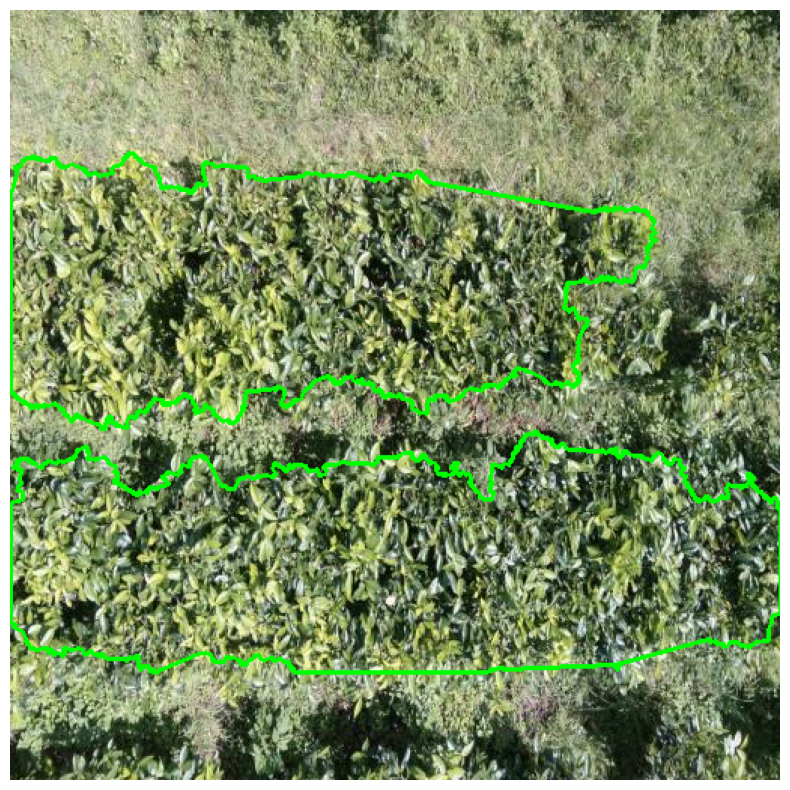

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width = image.shape[:2]

with open(label_path, "r") as f:
    lines = f.readlines()

for line in lines:
    values = line.strip().split()

    # Class ID
    class_id = int(values[0])

    # Normalized polygon coordinates
    coords = np.array(
        list(map(float, values[1:]))
    ).reshape(-1, 2)

    # Convert normalized coordinates → pixels
    coords[:, 0] *= width
    coords[:, 1] *= height

    points = coords.astype(np.int32)

    # Draw polygon
    cv2.polylines(
        image,
        [points],
        isClosed=True,
        color=(0, 255, 0),
        thickness=2
    )

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off");

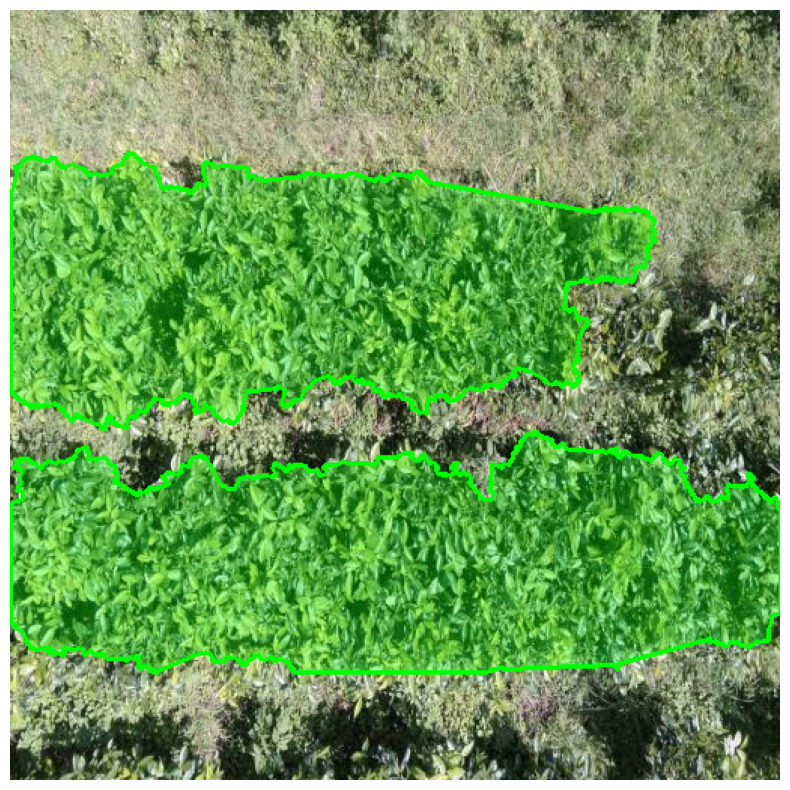

In [17]:
overlay = image.copy()

for line in lines:
    values = line.strip().split()

    coords = np.array(
        list(map(float, values[1:]))
    ).reshape(-1, 2)

    coords[:, 0] *= width
    coords[:, 1] *= height

    points = coords.astype(np.int32)

    cv2.fillPoly(
        overlay,
        [points],
        color=(0, 255, 0)
    )

# Blend original + mask
result = cv2.addWeighted(image, 0.7, overlay, 0.3, 0)

plt.figure(figsize=(10, 10))
plt.imshow(result)
plt.axis("off");

# Comparing COCO polygon to YOLO polygon to see how accurate it is and whether we need to correct it

In [18]:
import json
import numpy as np
from pathlib import Path

# Load original COCO annotations
json_path = Path(
    "data/Tea Plantation.v37i.coco-segmentation/train/_annotations.coco.json"
)

with open(json_path, "r") as f:
    coco = json.load(f)

# Pick the same image
image_name = image_path.name

# Find its COCO image entry
coco_image = next(
    img for img in coco["images"]
    if Path(img["file_name"]).name == image_name
)

image_id = coco_image["id"]
width = coco_image["width"]
height = coco_image["height"]

# Find annotations for this image
annotations = [
    ann for ann in coco["annotations"]
    if ann["image_id"] == image_id
]

print("Image:", image_name)
print("Size:", width, "x", height)
print("COCO annotations:", len(annotations))

# Compare the first annotation
original = annotations[0]["segmentation"][0]

original = np.array(original).reshape(-1, 2)

# Read our converted YOLO label
with open(label_path, "r") as f:
    yolo_line = f.readline().strip().split()

yolo_coords = np.array(
    list(map(float, yolo_line[1:]))
).reshape(-1, 2)

# Convert YOLO coordinates back to pixels
yolo_pixels = yolo_coords * np.array([width, height])

print("Original polygon points:", len(original))
print("YOLO polygon points:", len(yolo_pixels))

print("\nFirst 5 original points:")
print(original[:5])

print("\nFirst 5 reconstructed points:")
print(yolo_pixels[:5])

print("\nMaximum coordinate difference:",
      np.max(np.abs(original - yolo_pixels)))

Image: IMG_260407_022055_0058_RGB_JPG.rf.dd4948f3daf7933d54b5e27701b531c3.jpg
Size: 512 x 512
COCO annotations: 2
Original polygon points: 516
YOLO polygon points: 516

First 5 original points:
[[     427.56      138.96]
 [        427      139.26]
 [     424.67      135.41]
 [        423      134.67]
 [     422.44      133.48]]

First 5 reconstructed points:
[[     427.56      138.96]
 [        427      139.26]
 [     424.67      135.41]
 [        423      134.67]
 [     422.44      133.48]]

Maximum coordinate difference: 0.00025600000000736145


In [21]:
# Testing if the model can load the dataset and actually train from it
from ultralytics import YOLO

model = YOLO("yolo26n-seg.pt")

results = model.train(
    data="data/tea_plantation_yolo/data.yaml",
    epochs=5,
    imgsz=512,
    batch=8,
    device="mps",
)

Ultralytics 8.4.173 🚀 Python-3.12.7 torch-2.8.0 MPS (Apple M3)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/tea_plantation_yolo/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, 

In [22]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

run_dir = Path("/Users/yatharthnehva/runs/segment/train-2")

df = pd.read_csv(run_dir / "results.csv")

display(df)

,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/l1_loss,train/sem_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),...,metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/l1_loss,val/sem_loss,lr/pg0,lr/pg1,lr/pg2
0,1,490.177,1.83119,3.52918,3.04794,0.02001,3.06578,0.40256,0.49375,0.38996,...,0.20414,0.09262,1.46981,3.18985,2.50905,0.02619,0,0.000663,0.000663,0.000663
1,2,1255.540,1.64777,2.88540,2.31136,0.01754,1.88393,0.43098,0.22991,0.19592,...,0.11716,0.05530,1.43823,2.68953,1.94449,0.02572,0,0.001066,0.001066,0.001066
2,3,2196.600,1.60589,2.68962,2.06989,0.01743,1.67813,0.50880,0.26027,0.23765,...,0.13704,0.06606,1.40957,2.59532,1.71157,0.02345,0,0.001206,0.001206,0.001206
3,4,3709.440,1.56764,2.54730,1.89614,0.01698,1.55016,0.48128,0.17009,0.15982,...,0.09703,0.04734,1.39104,2.33227,1.54209,0.02429,0,0.000812,0.000812,0.000812
4,5,5197.310,1.48236,2.40221,1.73293,0.01519,1.47110,0.43217,0.11339,0.10259,...,0.06246,0.03176,1.25092,2.27335,1.39473,0.02037,0,0.000416,0.000416,0.000416


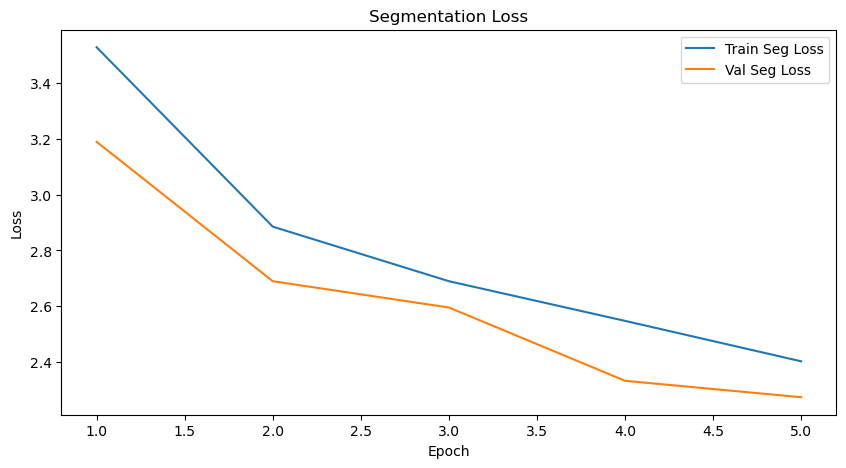

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(df["epoch"], df["train/seg_loss"], label="Train Seg Loss")
plt.plot(df["epoch"], df["val/seg_loss"], label="Val Seg Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Segmentation Loss")
plt.legend()
plt.show()

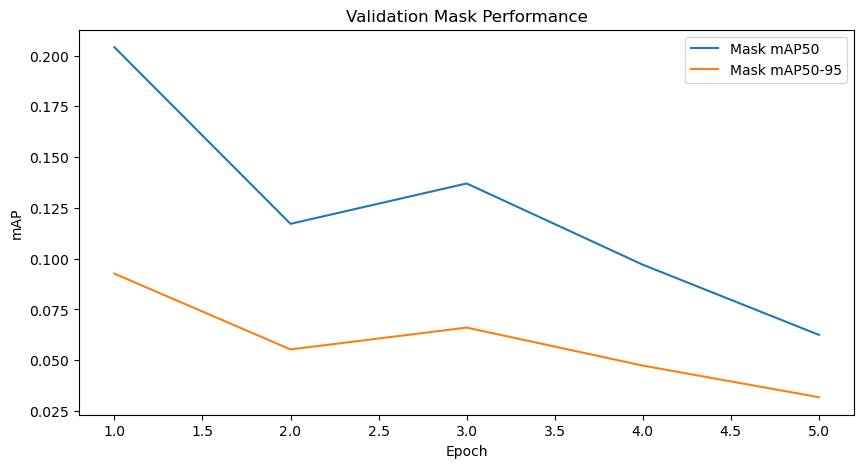

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(df["epoch"], df["metrics/mAP50(M)"], label="Mask mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(M)"], label="Mask mAP50-95")

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Validation Mask Performance")
plt.legend()
plt.show()

In [25]:
from ultralytics import YOLO

model = YOLO(
    "/Users/yatharthnehva/runs/segment/train-2/weights/best.pt"
)

In [27]:
results = model.predict(
    source="data/tea_plantation_yolo/valid/images",
    device="mps",
    imgsz=512,
    conf=0.25,
    max_det=50,
    save=False,
    verbose=True
)


image 1/134 /Users/yatharthnehva/Desktop/CVP_Project/data/tea_plantation_yolo/valid/images/DJI_20240822103108_0001_V_JPG.rf.44bcc28880ac3d1eaf3f05bbfd00eb5d.jpg: 512x512 13 teas, 121.9ms
image 2/134 /Users/yatharthnehva/Desktop/CVP_Project/data/tea_plantation_yolo/valid/images/DJI_20240822104253_0012_V_JPG.rf.83d0917f9b761128155e9ab37dcc4360.jpg: 512x512 12 teas, 307.4ms
image 3/134 /Users/yatharthnehva/Desktop/CVP_Project/data/tea_plantation_yolo/valid/images/DJI_20240822104258_0013_V_JPG.rf.ade30740f5f7fec00a645064e5792b2b.jpg: 512x512 48 teas, 130.8ms
image 4/134 /Users/yatharthnehva/Desktop/CVP_Project/data/tea_plantation_yolo/valid/images/DJI_20240822105601_0008_V_JPG.rf.6b8ff0c0cee54b504f300b84d5387408.jpg: 512x512 9 teas, 26.0ms
image 5/134 /Users/yatharthnehva/Desktop/CVP_Project/data/tea_plantation_yolo/valid/images/DJI_20240822105610_0010_V_JPG.rf.43d4f303b247f6ab8d3456c47131ae8c.jpg: 512x512 47 teas, 25.3ms
image 6/134 /Users/yatharthnehva/Desktop/CVP_Project/data/tea_plant

In [28]:
from IPython.display import display

display(results[5].plot())

array([[[  9,   2,   7],
        [  6,   0,   5],
        [  0,   0,   3],
        ...,
        [  2,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  5,   0,   3],
        [  2,   0,   3],
        [  0,   0,   3],
        ...,
        [  2,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  4,   0,   1],
        [  2,   0,   1],
        [  0,   0,   1],
        ...,
        [  2,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[255,  42,   4],
        [255,  42,   4],
        [ 58,  12,   1],
        ...,
        [  0,   1,   0],
        [  0,   1,   0],
        [  0,   0,   0]],

       [[255,  42,   4],
        [255,  42,   4],
        [ 99,  17,   0],
        ...,
        [  0,   1,   0],
        [  0,   1,   0],
        [  0,   3,   2]],

       [[255,  42,   4],
        [255,  42,   4],
        [255,  42,   4],
        ...,
        [  0,   1,   0],
        [  0,   1,   0],
        [  0,   3,   2]]

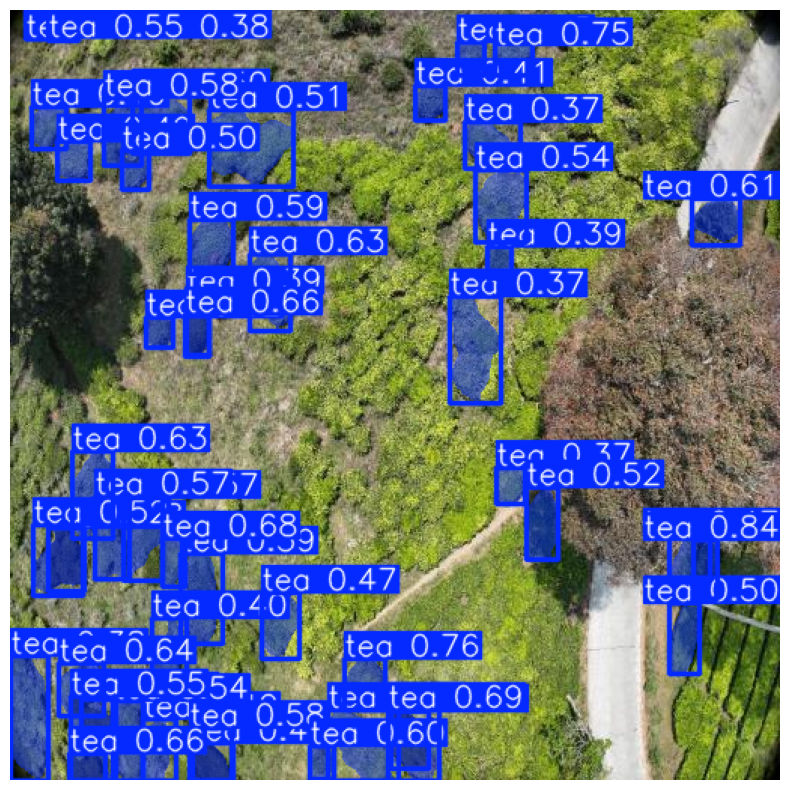

In [29]:
import matplotlib.pyplot as plt

img = results[5].plot()

plt.figure(figsize=(10, 10))
plt.imshow(img[:, :, ::-1])  # BGR → RGB
plt.axis("off")
plt.show()

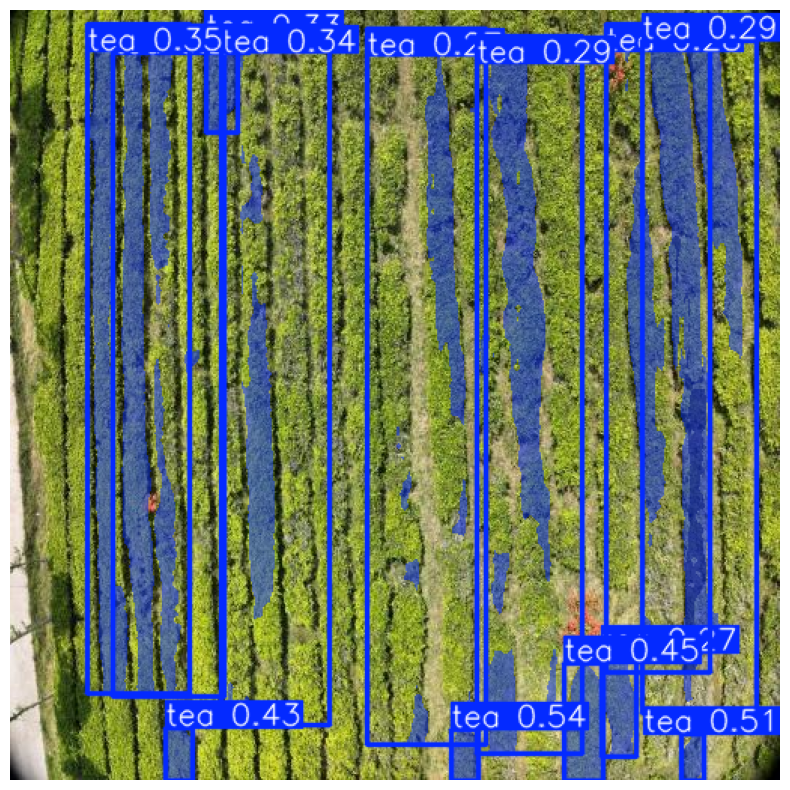

In [30]:
img = results[0].plot()

plt.figure(figsize=(10, 10))
plt.imshow(img[:, :, ::-1])
plt.axis("off")
plt.show()

Number of ground-truth instances: 58


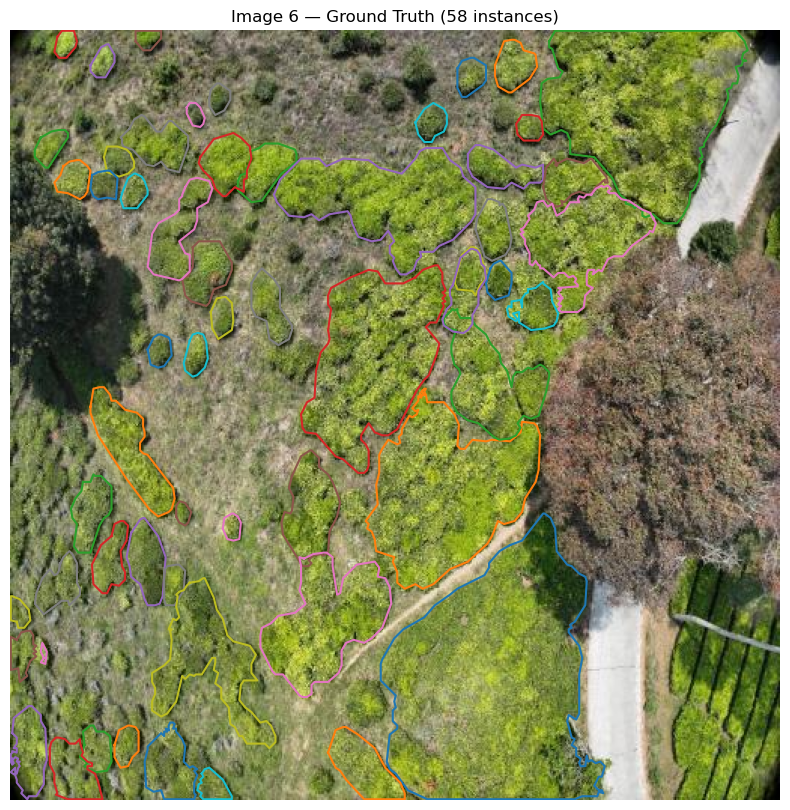

In [31]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# Image 6
img_path = Path(
    "data/tea_plantation_yolo/valid/images/"
    "DJI_20240822105903_0011_V_JPG.rf.b0eb8a2158b9ccb5fa20ba66910c44f1.jpg"
)

label_path = Path(
    "data/tea_plantation_yolo/valid/labels/"
    "DJI_20240822105903_0011_V_JPG.rf.b0eb8a2158b9ccb5fa20ba66910c44f1.txt"
)

# Load image
img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

# Load labels
with open(label_path) as f:
    labels = f.readlines()

print("Number of ground-truth instances:", len(labels))

# Plot
plt.figure(figsize=(10, 10))
plt.imshow(img)

for line in labels:
    values = list(map(float, line.strip().split()))

    # First value = class
    cls = int(values[0])

    # Remaining values = x,y polygon coordinates
    coords = values[1:]

    points = []

    for i in range(0, len(coords), 2):
        x = int(coords[i] * w)
        y = int(coords[i + 1] * h)
        points.append([x, y])

    # Close polygon
    points.append(points[0])

    xs = [p[0] for p in points]
    ys = [p[1] for p in points]

    plt.plot(xs, ys)

plt.axis("off")
plt.title(f"Image 6 — Ground Truth ({len(labels)} instances)")
plt.show()

In [32]:
for conf in [0.25, 0.50, 0.75]:
    r = model.predict(
        source=results[5].path,
        device="mps",
        imgsz=512,
        conf=conf,
        max_det=100,
        verbose=False
    )[0]

    print(f"Confidence {conf}: {len(r.boxes)} detections")

Confidence 0.25: 89 detections
Confidence 0.5: 27 detections
Confidence 0.75: 2 detections


In [33]:
from ultralytics import YOLO

pretrained_model = YOLO("yolo26n-seg.pt")

In [34]:
r = pretrained_model.predict(
    source=results[5].path,
    device="mps",
    imgsz=512,
    conf=0.25,
    max_det=100,
    verbose=False
)[0]

print("Pretrained model detections:", len(r.boxes))

display(r.plot())

Pretrained model detections: 0


array([[[9, 2, 7],
        [6, 0, 5],
        [0, 0, 3],
        ...,
        [2, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[5, 0, 3],
        [2, 0, 3],
        [0, 0, 3],
        ...,
        [2, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[4, 0, 1],
        [2, 0, 1],
        [0, 0, 1],
        ...,
        [2, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[6, 1, 0],
        [5, 3, 2],
        [0, 3, 1],
        ...,
        [0, 1, 0],
        [0, 1, 0],
        [0, 0, 0]],

       [[4, 0, 0],
        [4, 2, 1],
        [0, 2, 0],
        ...,
        [0, 1, 0],
        [0, 1, 0],
        [0, 3, 2]],

       [[4, 0, 0],
        [3, 1, 0],
        [0, 1, 0],
        ...,
        [0, 1, 0],
        [0, 1, 0],
        [0, 3, 2]]], dtype=uint8)

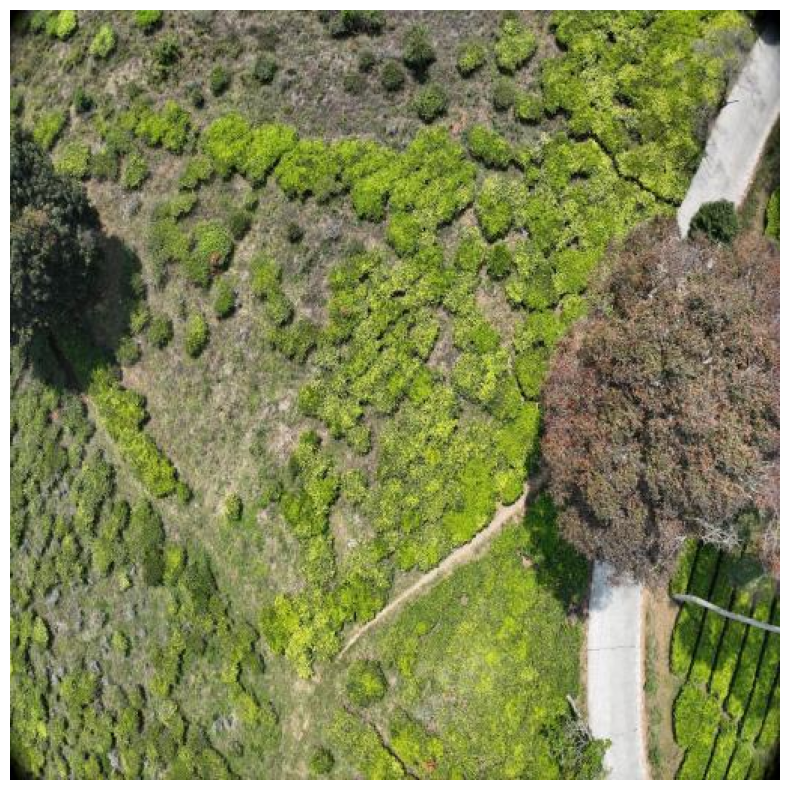

In [36]:
import matplotlib.pyplot as plt

img = r.plot()

plt.figure(figsize=(10, 10))
plt.imshow(img[:, :, ::-1])  # BGR → RGB
plt.axis("off")
plt.show()

In [37]:
print("Pretrained model detections:", len(r.boxes))

Pretrained model detections: 0
